# Модель прогнозирования вовлечённости твитов

Этот ноутбук содержит реализацию модели, предназначенной для оценки уровня вовлечённости твита (по шкале от 0 до 10) на основе его текста, дня недели и времени публикации. Он может использоваться для предсказания потенциальной эффективности поста ещё до публикации.


## Основные этапы:
1. Очистка и подготовка данных

    * Загрузка датасета

    * Удаление пропущенных значений

    * Очистка текстов твитов от ссылок, упоминаний, спецсимволов и стоп-слов

2. Формирование целевой переменной

    * Расчёт метрики вовлечённости на основе лайков, ретвитов и охвата

    * Применение логарифмического сглаживания и нормализация значений в диапазон от 0 до 10

3. Преобразование признаков

    * Преобразование текста в эмбеддинги с помощью BERT

    * One-Hot кодирование признака Weekday

    * Циклическое преобразование признака Hour (в синус и косинус)



4. Обучение модели

    * Сравнение нескольких регрессионных моделей

    * Выбор модели с наилучшими метриками (в итоге — RandomForestRegressor)

5. Сохранение результатов

    * Сохранение обученной модели и препроцессоров (OneHotEncoder, и др.)

    * Подготовка функции инференса predict_engagement_rf для последующего использования (в т.ч. в агенте)

In [1]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertTokenizer, BertModel
import numpy as np
import pandas as pd

In [2]:
tweets_df = pd.read_csv("Twitterdatainsheets.csv")
tweets_df

C:\Users\oklad\AppData\Local\Temp\ipykernel_15264\2203785831.py:1: DtypeWarning: Columns (3,4,5,6,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  tweets_df = pd.read_csv("Twitterdatainsheets.csv")


,index,TweetID,Weekday,Hour,Day,Lang,IsReshare,Reach,RetweetCount,Likes,Klout,Sentiment,text,LocationID,UserID
0,0,tw-682712873332805633,Thursday,17,31,en,False,44.0,0.0,0.0,35.0,0.0,We are hiring: Senior Software Engineer - Prot...,3751.0,tw-40932430
1,1,tw-682713045357998080,Thursday,17,31,en,True,1810.0,5.0,0.0,53.0,2.0,RT @CodeMineStatus: This is true Amazon Web Se...,3989.0,tw-3179389829
2,2,tw-682713219375476736,Thursday,17,31,en,False,282.0,0.0,0.0,47.0,0.0,Devops Engineer Aws Ansible Cassandra Mysql Ub...,3741.0,tw-4624808414
3,3,tw-682713436967579648,Thursday,17,31,en,False,2087.0,4.0,0.0,53.0,0.0,Happy New Year to all those AWS instances of o...,3753.0,tw-356447127
4,4,tw-682714048199311366,Thursday,17,31,en,False,953.0,0.0,0.0,47.0,0.0,Amazon is hiring! #Sr. #International Tax Mana...,3751.0,tw-3172686669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206290,206290,tw-443876086,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
206291,206291,tw-565013710,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
206292,206292,tw-322341885,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
206293,206293,tw-3304550634,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
tweets_df.columns

Index(['index', 'TweetID', ' Weekday', ' Hour', ' Day', ' Lang', ' IsReshare',
       ' Reach', ' RetweetCount', ' Likes', ' Klout', ' Sentiment', ' text',
       ' LocationID', ' UserID'],
      dtype='object')

In [5]:
tweets_df[' Sentiment'].value_counts().head(40)

 Sentiment
 0.000000    67424
 1.000000     8771
 2.000000     8587
 3.000000     3945
-1.000000     1770
-2.000000     1729
 1.500000     1164
 4.000000      798
 2.500000      693
 0.500000      552
-3.000000      497
 0.400000      278
-0.500000      277
-1.500000      223
-4.000000      213
 0.160000      167
 1.666667      162
 2.666667      160
 0.120000      146
 1.333333      131
-2.500000      100
 1.750000       83
 0.240000       76
 0.666667       75
 0.300000       73
 2.333333       70
-0.666667       70
 0.750000       70
 0.333333       65
-0.120000       65
 0.150000       62
 3.500000       60
-0.333333       58
 0.250000       52
-0.300000       51
 0.200000       50
-2.333333       46
-6.000000       46
 1.250000       45
-0.240000       43
Name: count, dtype: int64

# Предобработка данных и очистка текста

В этом блоке осуществляется начальная подготовка датасета твитов для последующего анализа:
### 1. Загрузка и очистка датасета
- Загружается CSV-файл с данными о твитах.
- Удаляются строки с пропущенными значениями в ключевых признаках: `text`, `Likes`, `Reach`, `RetweetCount`, `Klout`, `Sentiment`, `Weekday`, `Hour`.
- Названия столбцов очищаются от лишних пробеов.

### 2. Очистка текста твитов
- Ссылки заменяются на соответствующие домены в квадратных скобках (например, `[youtube.com]`).
- Удаляются упоминания пользователей (`@username`) и лишние символы, за исключением букв, цифр, пробелов, `#`, `[]` и точек.
- Текст приводится к нижнему регистру.
- Выполняется токенизация и удаление английских стоп-слов.
- Очищенный текст сохраняется в отдельный столбец `cean_text`.

### 3. Отбор признаков для анализа
- Формируется подмножество признаков, включая `TweetID`, очищенный текст `clean_text`, а также числовые и категориальные признаки, необходимые для моделирования.


In [4]:
import pandas as pd
import re
from urllib.parse import urlparse

# Загрузка CSV и очистка названий столбцов
tweets_df = pd.read_csv("Twitterdatainsheets.csv", low_memory=False)
tweets_df.columns = tweets_df.columns.str.strip()

# Удаляем строки с пропущенными значениями в ключевых столбцах
tweets_df.dropna(subset=["text", "Likes", "RetweetCount", "Reach", "Klout", "Sentiment", "Weekday", "Hour"], inplace=True)

# Функция замены ссылок на домены
def replace_links_with_domains(text):
    urls = re.findall(r"http\S+", text)
    for url in urls:
        domain = urlparse(url).netloc.replace("www.", "")
        text = text.replace(url, f"[{domain}]")
    return text

# Финальная функция предобработки для BERTweet
def preprocess_for_berttweet(text):
    text = replace_links_with_domains(text)               # заменяем ссылки на [domain.com]
    text = re.sub(r"@\w+", "<user>", text)                # заменяем упоминания на <user>
    text = re.sub(r"\s+", " ", text)                      # убираем множественные пробелы
    return text.strip()                                   # обрезаем пробелы по краям

# Применяем предобработку
tweets_df["clean_text"] = tweets_df["text"].apply(preprocess_for_berttweet)

# Оставляем только нужные столбцы
columns_to_keep = ["TweetID", "clean_text", "Likes", "RetweetCount", "Reach", "Klout", "Sentiment", "Weekday", "Hour", "text"]
tweets_df = tweets_df[columns_to_keep]

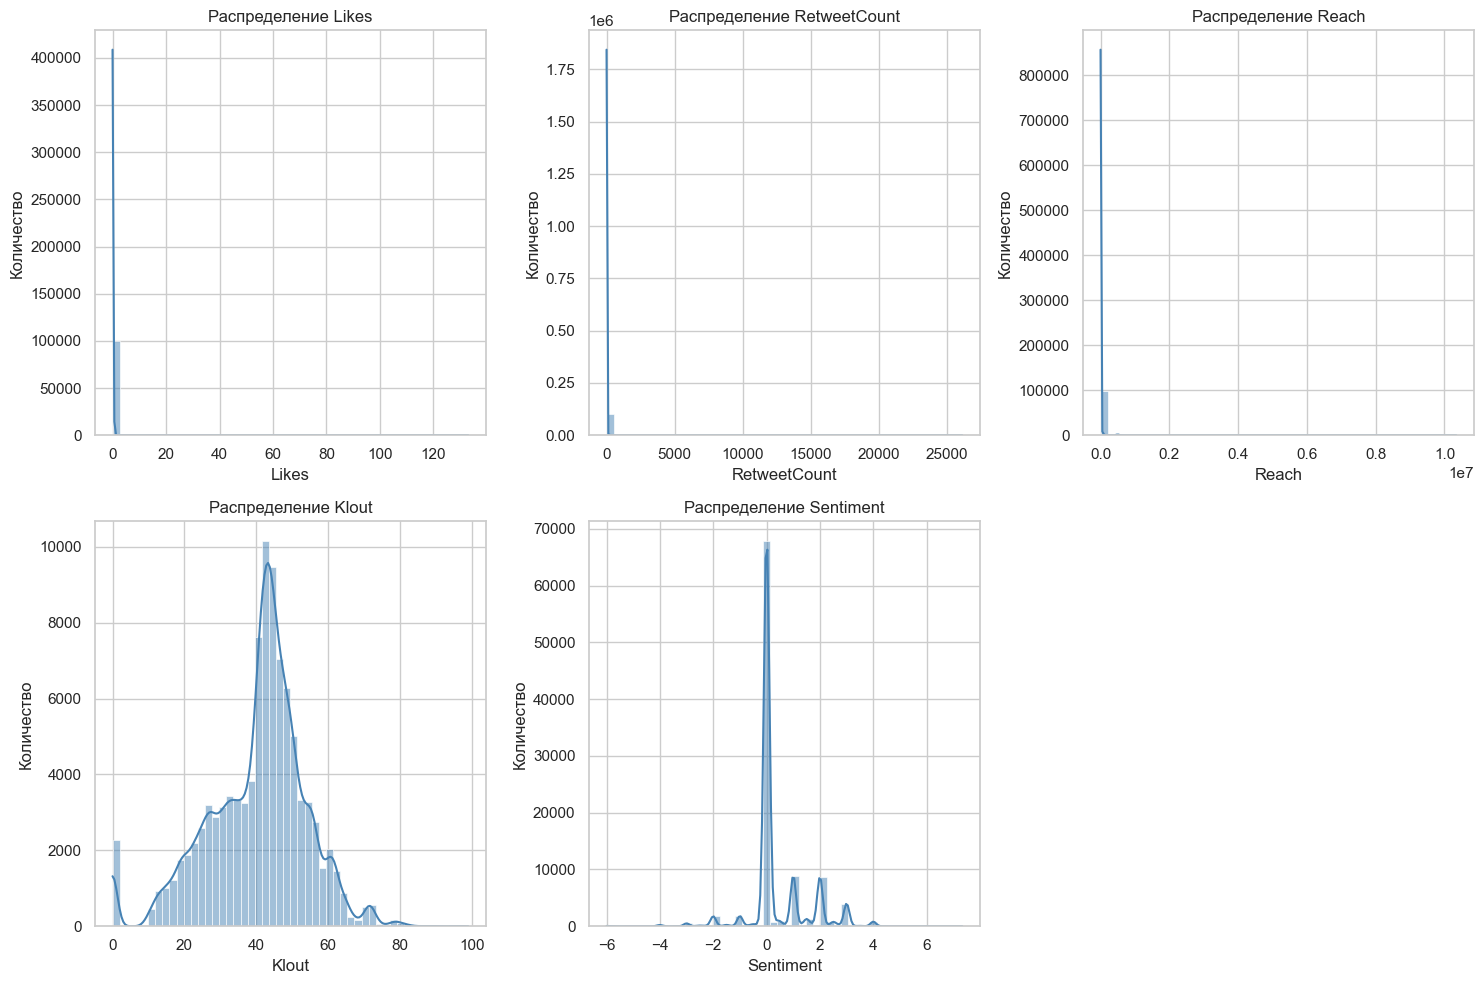

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Устанавливаем стиль графиков
sns.set(style="whitegrid")

# Список интересующих столбцов
columns_to_plot = ["Likes", "RetweetCount", "Reach", "Klout", "Sentiment"]

# Размер всего полотна
plt.figure(figsize=(15, 10))

# Проходимся по каждому столбцу и строим график
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(tweets_df[col], bins=50, kde=True, color="steelblue")
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")

# Автоматическая подгонка компоновки
plt.tight_layout()
plt.show()

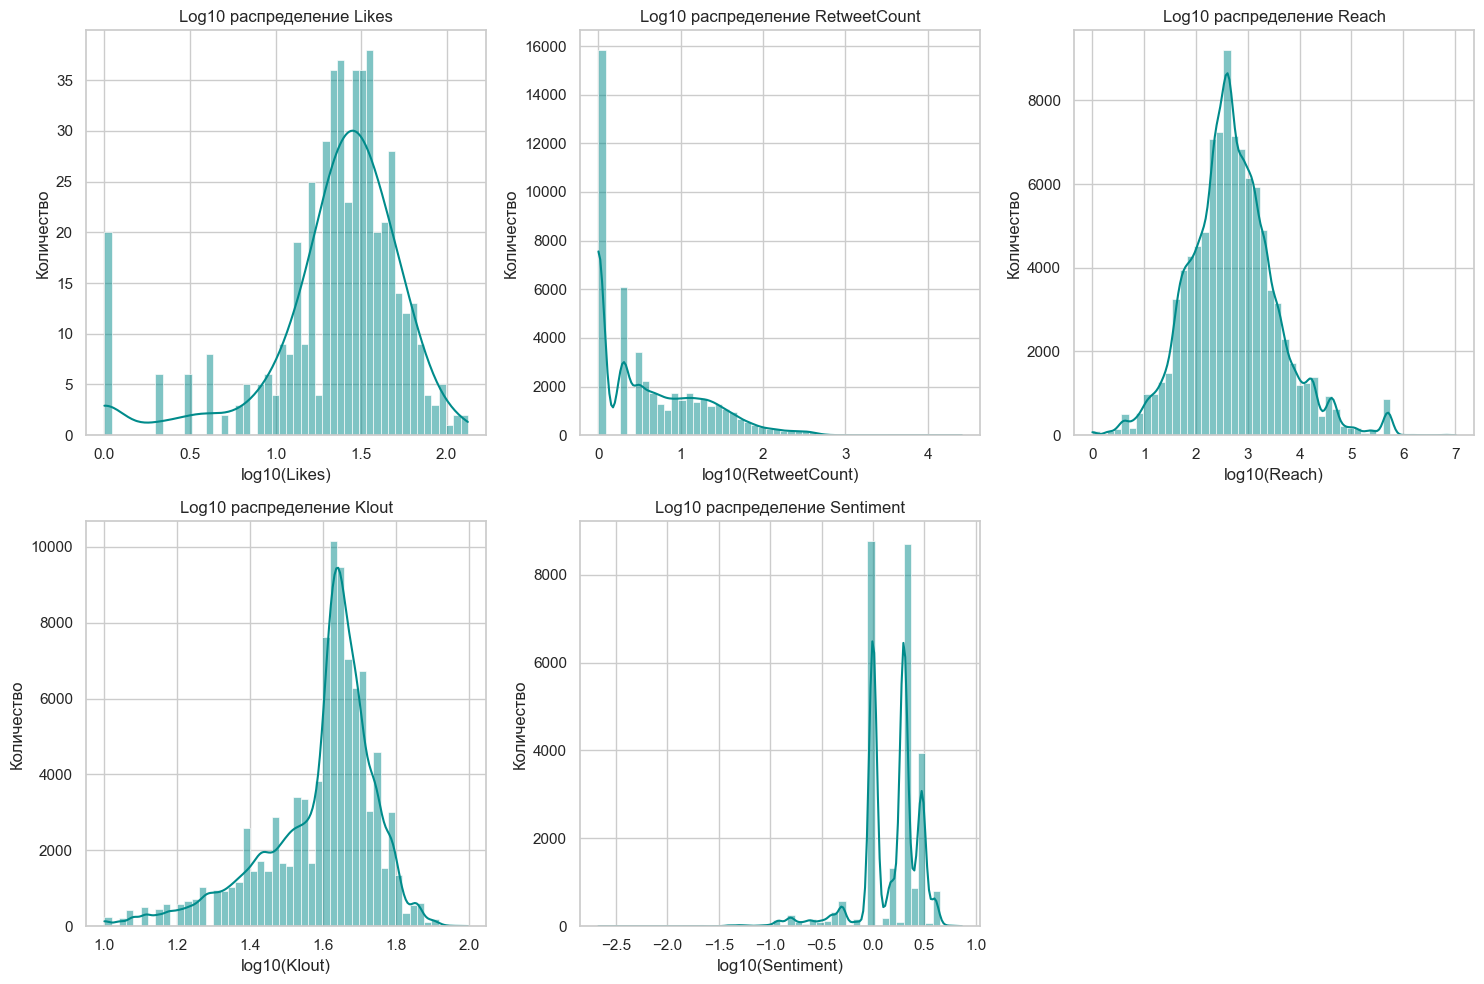

In [6]:
sns.set(style="whitegrid")

columns_to_plot = ["Likes", "RetweetCount", "Reach", "Klout", "Sentiment"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(2, 3, i)
    
    # Удаляем нули перед логарифмом
    non_zero_values = tweets_df[col][tweets_df[col] > 0]
    
    # Применяем логарифм (по основанию 10)
    log_values = np.log10(non_zero_values)
    
    sns.histplot(log_values, bins=50, kde=True, color="darkcyan")
    plt.title(f"Log10 распределение {col}")
    plt.xlabel(f"log10({col})")
    plt.ylabel("Количество")

plt.tight_layout()
plt.show()

# Расчёт метрики вовлечённости:
В этом блоке вычисляется оптимизированная метрика, отражающая уровень вовлечённости аудитории. Она представляет собой сбалансированную комбинацию лайков, ретвитов и охвата, скорректированную с учётом логарифмического сглаживания и нормализации.

## Первый вариант итоговой метрики (не удачный) 

In [7]:
tweets_df = tweets_df.copy()  # создаём независимую копию, чтобы убрать предупреждение

tweets_df["like_rate"] = tweets_df["Likes"] / tweets_df["Reach"]
tweets_df["retweet_rate"] = tweets_df["RetweetCount"] / tweets_df["Reach"]
tweets_df["Engagement_raw"] = tweets_df["like_rate"] + 2 * tweets_df["retweet_rate"]

p1 = tweets_df["Engagement_raw"].quantile(0.01)
p99 = tweets_df["Engagement_raw"].quantile(0.99)

tweets_df["Engagement_score"] = 10 * (tweets_df["Engagement_raw"] - p1) / (p99 - p1)
tweets_df["Engagement_score"] = tweets_df["Engagement_score"].clip(0, 10)

# Обрезаем 1% крайних значений
filtered = tweets_df[
    (tweets_df["Engagement_score"] > tweets_df["Engagement_score"].quantile(0.01)) &
    (tweets_df["Engagement_score"] < tweets_df["Engagement_score"].quantile(0.99))
]

In [8]:
tweets_df

,TweetID,clean_text,Likes,RetweetCount,Reach,Klout,Sentiment,Weekday,Hour,text,like_rate,retweet_rate,Engagement_raw,Engagement_score
0,tw-682712873332805633,We are hiring: Senior Software Engineer - Prot...,0.0,0.0,44.0,35.0,0.0,Thursday,17,We are hiring: Senior Software Engineer - Prot...,0.0,0.000000,0.000000,0.000000
1,tw-682713045357998080,RT <user>: This is true Amazon Web Services [a...,0.0,5.0,1810.0,53.0,2.0,Thursday,17,RT @CodeMineStatus: This is true Amazon Web Se...,0.0,0.002762,0.005525,0.017572
2,tw-682713219375476736,Devops Engineer Aws Ansible Cassandra Mysql Ub...,0.0,0.0,282.0,47.0,0.0,Thursday,17,Devops Engineer Aws Ansible Cassandra Mysql Ub...,0.0,0.000000,0.000000,0.000000
3,tw-682713436967579648,Happy New Year to all those AWS instances of o...,0.0,4.0,2087.0,53.0,0.0,Thursday,17,Happy New Year to all those AWS instances of o...,0.0,0.001917,0.003833,0.012192
4,tw-682714048199311366,Amazon is hiring! #Sr. #International Tax Mana...,0.0,0.0,953.0,47.0,0.0,Thursday,17,Amazon is hiring! #Sr. #International Tax Mana...,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,tw-716349486742700032,RT <user>: Dekhana thoda dhirese darlingmene k...,0.0,1.0,1143.0,49.0,1.0,Saturday,13,RT @iiManjula: Dekhana thoda dhirese darlingme...,0.0,0.000875,0.001750,0.005565
99996,tw-716349615340199937,I added a video to a <user> playlist [youtube....,0.0,0.0,763.0,29.0,0.0,Saturday,13,I added a video to a @YouTube playlist https:/...,0.0,0.000000,0.000000,0.000000
99997,tw-716351557516722176,RT <user>: Test your iOS Android &amp; web app...,0.0,435.0,122.0,17.0,1.0,Saturday,13,RT @awscloud: Test your iOS Android &amp; web ...,0.0,3.565574,7.131148,10.000000
99998,tw-716352501860196352,RT <user>: Serverless Offline: Emulate AWS Lam...,0.0,30.0,287.0,42.0,0.0,Saturday,13,RT @goserverless: Serverless Offline: Emulate ...,0.0,0.104530,0.209059,0.664935


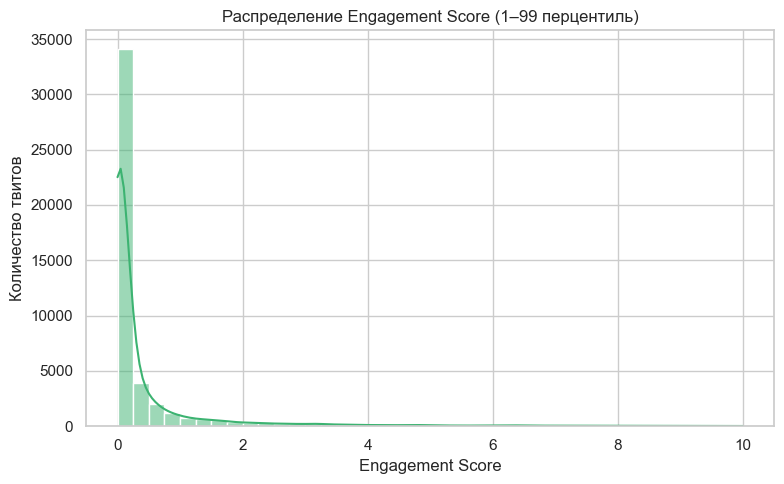

In [9]:
# Обрезаем 1% крайних значений
filtered = tweets_df[
    (tweets_df["Engagement_score"] > tweets_df["Engagement_score"].quantile(0.01)) &
    (tweets_df["Engagement_score"] < tweets_df["Engagement_score"].quantile(0.99))
]

plt.figure(figsize=(8, 5))
sns.histplot(filtered["Engagement_score"], bins=40, kde=True, color="mediumseagreen")
plt.title("Распределение Engagement Score (1–99 перцентиль)")
plt.xlabel("Engagement Score")
plt.ylabel("Количество твитов")
plt.tight_layout()
plt.show()

## Второй вариант итоговой метрики

In [10]:
# Приведение к числам
tweets_df["Likes"] = pd.to_numeric(tweets_df["Likes"], errors="coerce")
tweets_df["RetweetCount"] = pd.to_numeric(tweets_df["RetweetCount"], errors="coerce")
tweets_df["Reach"] = pd.to_numeric(tweets_df["Reach"], errors="coerce")
tweets_df = tweets_df.dropna(subset=["Likes", "RetweetCount", "Reach"])
tweets_df = tweets_df[tweets_df["Reach"] > 0].copy()

# Параметры лог-сглаженной формулы
a = 1
b = 2
gamma = 0.5

# Расчёт Engagement_raw
tweets_df["Engagement_raw"] = (
    (a * np.log1p(tweets_df["Likes"]) + b * np.log1p(tweets_df["RetweetCount"])) /
    (np.log1p(tweets_df["Reach"]) ** gamma)
)

# Масштабирование по логарифму сырой метрики, затем нормализация в [0, 10]
tweets_df["Engagement_log_scaled"] = np.log1p(tweets_df["Engagement_raw"])

p1 = tweets_df["Engagement_log_scaled"].quantile(0.01)
p99 = tweets_df["Engagement_log_scaled"].quantile(0.99)

tweets_df["Engagement_score"] = 10 * (tweets_df["Engagement_log_scaled"] - p1) / (p99 - p1)
tweets_df["Engagement_score"] = tweets_df["Engagement_score"].clip(0, 10)

# Обрезаем 1% крайних значений
filtered = tweets_df[
    (tweets_df["Engagement_score"] > tweets_df["Engagement_score"].quantile(0.01)) &
    (tweets_df["Engagement_score"] < tweets_df["Engagement_score"].quantile(0.99))
]

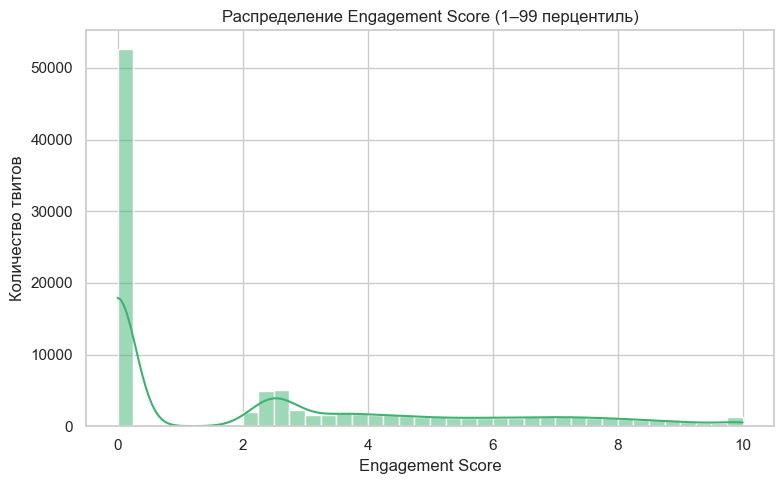

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(tweets_df["Engagement_score"], bins=40, kde=True, color="mediumseagreen")
plt.title("Распределение Engagement Score (1–99 перцентиль)")
plt.xlabel("Engagement Score")
plt.ylabel("Количество твитов")
plt.tight_layout()
plt.show()

# Удаление записей с нулевой вовлеченностью
Записи с нулевым значением метрики необходимо удалить, поскольку они не содержат ни одного лайка или ретвита, не несут информации о вовлечённости и могут исказить процесс обучения моделей, снижая их способность выявлять закономерности.

In [12]:
tweets_df['Engagement_score'].value_counts()

Engagement_score
0.000000     52603
10.000000      999
3.759116        52
4.341961        43
3.666424        39
             ...  
8.868987         1
7.529089         1
5.750375         1
2.267797         1
7.980991         1
Name: count, Length: 26060, dtype: int64

In [13]:
tweets_df = tweets_df[tweets_df['Engagement_score']!=0]
tweets_df

,TweetID,clean_text,Likes,RetweetCount,Reach,Klout,Sentiment,Weekday,Hour,text,like_rate,retweet_rate,Engagement_raw,Engagement_score,Engagement_log_scaled
1,tw-682713045357998080,RT <user>: This is true Amazon Web Services [a...,0.0,5.0,1810.0,53.0,2.0,Thursday,17,RT @CodeMineStatus: This is true Amazon Web Se...,0.0,0.002762,1.308374,4.918559,0.836543
3,tw-682713436967579648,Happy New Year to all those AWS instances of o...,0.0,4.0,2087.0,53.0,0.0,Thursday,17,Happy New Year to all those AWS instances of o...,0.0,0.001917,1.164247,4.539494,0.772072
8,tw-682717967965110273,Red line vs. green line: Reporting on the most...,0.0,1.0,4893.0,49.0,0.0,Thursday,17,Red line vs. green line: Reporting on the most...,0.0,0.000204,0.475614,2.287608,0.389074
9,tw-682718048080519168,RT <user>: We developed a test drive on AWS. W...,0.0,6.0,2868.0,51.0,2.0,Thursday,17,RT @HPE_BigData: We developed a test drive on ...,0.0,0.002092,1.379270,5.096421,0.866794
10,tw-682719022958292992,RT <user>: AWS CloudFormation now supports AWS...,0.0,51.0,86.0,16.0,2.0,Thursday,17,RT @awscloud: AWS CloudFormation now supports ...,0.0,0.593023,3.739460,9.148242,1.555923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,tw-716349383688720385,RT <user>: .<user> built a #DataWarehouse that...,0.0,15.0,415.0,44.0,0.0,Saturday,13,RT @awscloud: .@Jaspersoft built a #DataWareho...,0.0,0.036145,2.258043,6.944579,1.181127
99995,tw-716349486742700032,RT <user>: Dekhana thoda dhirese darlingmene k...,0.0,1.0,1143.0,49.0,1.0,Saturday,13,RT @iiManjula: Dekhana thoda dhirese darlingme...,0.0,0.000875,0.522395,2.471114,0.420284
99997,tw-716351557516722176,RT <user>: Test your iOS Android &amp; web app...,0.0,435.0,122.0,17.0,1.0,Saturday,13,RT @awscloud: Test your iOS Android &amp; web ...,0.0,3.565574,5.541075,10.000000,1.878101
99998,tw-716352501860196352,RT <user>: Serverless Offline: Emulate AWS Lam...,0.0,30.0,287.0,42.0,0.0,Saturday,13,RT @goserverless: Serverless Offline: Emulate ...,0.0,0.104530,2.886070,7.980991,1.357398


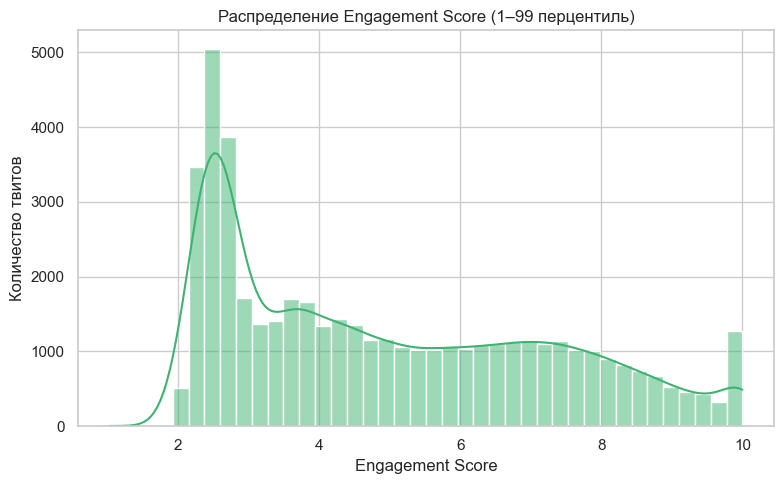

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(tweets_df["Engagement_score"], bins=40, kde=True, color="mediumseagreen")
plt.title("Распределение Engagement Score (1–99 перцентиль)")
plt.xlabel("Engagement Score")
plt.ylabel("Количество твитов")
plt.tight_layout()
plt.show()

# Препроцессинг признаков:
Текст твитов преобразуется в эмбеддинги с помощью модели BERT, после чего объединяется с другими признаками (например, Weekday, Hour), к которым также применяются соответствующие трансформации (нормализация, one-hot-кодирование, циклическое преобразование и др.).

### Убираем Klout и Sentiment. при инференсе модель не имеет этих признаков

In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

from transformers import AutoTokenizer, AutoModel

# Загрузка токенизатора и модели BERTweet
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=False)
model = AutoModel.from_pretrained("vinai/bertweet-base")

# Выбор устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Функция для получения эмбеддинга [CLS] из BERTweet
def get_berttweet_embedding(text):
    # Токенизация
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Получение выходов модели
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Используем [CLS] токен: первый токен
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    return cls_embedding

# Подготовка данных
tweets_sample = tweets_df.sample(n=47246, random_state=42).reset_index(drop=True)

# Получение BERT-эмбедингов
bert_embeddings = np.vstack(tweets_sample["clean_text"].apply(get_bert_embedding))

# OneHot кодирование Weekday
weekday_ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
weekday_encoded = weekday_ohe.fit_transform(tweets_sample[["Weekday"]])

# Циклическое кодирование часа
tweets_sample["Hour"] = pd.to_numeric(tweets_sample["Hour"], errors="coerce")
tweets_sample.dropna(subset=["Hour"], inplace=True)
tweets_sample["Hour_sin"] = np.sin(2 * np.pi * tweets_sample["Hour"] / 24)
tweets_sample["Hour_cos"] = np.cos(2 * np.pi * tweets_sample["Hour"] / 24)

# Объединение признаков
X_combined = np.hstack([
    bert_embeddings,
    weekday_encoded,
    tweets_sample[["Hour_sin", "Hour_cos"]].values
])

# Целевая переменная
y = tweets_sample["Engagement_score"]

# Деление на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

In [19]:
import joblib

# Сохраняем целевую переменную и признаки в .pkl файлы
joblib.dump(tweets_sample["Engagement_score"], "engagement_score.pkl")
joblib.dump(X_combined, "X_combined.pkl")

['X_combined.pkl']

In [20]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

# Обучение и оценка каждой модели
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}

# Вывод таблицы результатов
import pandas as pd
results_df = pd.DataFrame(results).T
results_df

,MSE,R2
LinearRegression,2.909407,0.449130
Ridge,2.912838,0.448480
Lasso,5.246496,0.006623
RandomForest,1.649242,0.687731


In [21]:
# Обучение полносвязной нейронной сети
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(RegressionNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_nn = RegressionNN(X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

# Обучение
for epoch in range(100):
    model_nn.train()
    optimizer.zero_grad()
    outputs = model_nn(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

# Оценка модели
model_nn.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_pred_nn = model_nn(X_test_tensor).cpu().detach().numpy().flatten()

# Добавим нейросетевую модель
results["NeuralNet"] = {
    "MSE": mean_squared_error(y_test, y_pred_nn),
    "R2": r2_score(y_test, y_pred_nn)
}

results_df = pd.DataFrame(results).T

results_df

,MSE,R2
LinearRegression,2.909407,0.449130
Ridge,2.912838,0.448480
Lasso,5.246496,0.006623
RandomForest,1.649242,0.687731
NeuralNet,4.107699,0.222244


In [22]:
from catboost import CatBoostRegressor

# Обучение CatBoost
catboost_model = CatBoostRegressor(verbose=0, random_state=42)
catboost_model.fit(X_train, y_train)

# Прогноз и метрики
y_pred_cat = catboost_model.predict(X_test)
mse_cat = mean_squared_error(y_test, y_pred_cat)
r2_cat = r2_score(y_test, y_pred_cat)

# Результаты
results["CatBoost"] = {
    "MSE": mse_cat,
    "R2": r2_cat
}

results_df = pd.DataFrame(results).T

results_df

,MSE,R2
LinearRegression,2.909407,0.449130
Ridge,2.912838,0.448480
Lasso,5.246496,0.006623
RandomForest,1.649242,0.687731
NeuralNet,4.107699,0.222244
CatBoost,1.835763,0.652415


# Заключение 
По результатам обучения и сравнения моделей на задаче прогнозирования вовлечённости, наилучшие показатели качества продемонстрировала модель RandomForest. Сохраним её для последующего использования в инференсе и интеграции.

In [190]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(mse, r2)

1.7695733263061126 0.6649470460210098


In [191]:
# Сохранение компонентов
joblib.dump(weekday_ohe, "weekday_ohe.pkl")
joblib.dump(model, "random_forest_model.pkl")

['random_forest_model.pkl']